In [5]:
#%pip install -r ../requirements.txt -q

In [6]:
import kagglehub
import os
import shutil

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [7]:
# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw", exist_ok=True)

path = kagglehub.dataset_download("sriharshaeedala/financial-fraud-detection-dataset")
print("Dataset downloaded to:", path)

target_dir = "../data/raw/financial-fraud-detection-dataset"
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)
shutil.copytree(path, target_dir)
print(f"Dataset copied to: {target_dir}")

path = target_dir

Dataset downloaded to: /Users/kayi/.cache/kagglehub/datasets/sriharshaeedala/financial-fraud-detection-dataset/versions/1
Dataset copied to: ../data/raw/financial-fraud-detection-dataset


In [8]:
csv_file = os.path.join(path, "Synthetic_Financial_datasets_log.csv")
print(f"Looking for file at: {csv_file}")


df = pd.read_csv(csv_file)
df.head()

Looking for file at: ../data/raw/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv


KeyboardInterrupt: 

In [ ]:
# class distribution
label_col = "isFraud"

counts = df[label_col].value_counts(dropna=False).sort_index()
pct = df[label_col].value_counts(normalize=True, dropna=False).sort_index() * 100

print("\n=== Class distribution (isFraud) ===")
for k in counts.index:
    print(f"{k}: {counts[k]:,}  ({pct[k]:.4f}%)")
imbalance_ratio = (counts.get(0, 0) / max(counts.get(1, 1), 1)) if 1 in counts else np.inf
print(f"Imbalance ratio (Non-fraud : Fraud) ≈ {imbalance_ratio:.1f}:1")


=== Class distribution (isFraud) ===
0: 6,354,407  (99.8709%)
1: 8,213  (0.1291%)
Imbalance ratio (Non-fraud : Fraud) ≈ 773.7:1


# Data Preprocessing
- drop useless columns
- convert isFraud to boolean
- onehotencode "type"
- train-test split (stratified)
- smote

In [ ]:
# remove unuse columns
df.drop(['step', 'nameOrig', 'nameDest'], axis=1, inplace=True)

# covert data type of some columns
df['isFraud'] = df['isFraud'].astype(bool)
df['isFlaggedFraud'] = df['isFlaggedFraud'].astype(bool)

# encodeing categorical vaiables
encoder = OneHotEncoder(sparse_output=False)
type_col = df['type'].values.reshape(-1, 1)
encoded_cols = encoder.fit_transform(type_col)
df = df.reset_index(drop=True)
df_encoded = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(['type']))
encoded_data = df.drop(columns=['type'])
encoded_data = pd.concat([encoded_data, df_encoded], axis=1)
encoded_data.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,170136.0,160296.36,0.0,0.0,False,False,0.0,0.0,0.0,1.0,0.0
1,1864.28,21249.0,19384.72,0.0,0.0,False,False,0.0,0.0,0.0,1.0,0.0
2,181.00,181.0,0.00,0.0,0.0,True,False,0.0,0.0,0.0,0.0,1.0
3,181.00,181.0,0.00,21182.0,0.0,True,False,0.0,1.0,0.0,0.0,0.0
4,11668.14,41554.0,29885.86,0.0,0.0,False,False,0.0,0.0,0.0,1.0,0.0


### Train-Test Split

In [ ]:
# split data into features and target
X = encoded_data.drop(columns=['isFraud'])
y = encoded_data['isFraud']

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Applying SMOTE

In [ ]:
# apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train_smoted, y_train_smoted = smote.fit_resample(X_train, y_train)

smote_df = pd.concat([X_train_smoted, y_train_smoted], axis=1).reset_index(drop=True)

# class distribution after smote
counts = smote_df[label_col].value_counts(dropna=False).sort_index()
pct = smote_df[label_col].value_counts(normalize=True, dropna=False).sort_index() * 100

print("\n=== Class distribution (isFraud) ===")
for k in counts.index:
    print(f"{k}: {counts[k]:,}  ({pct[k]:.4f}%)")
imbalance_ratio = (counts.get(0, 0) / max(counts.get(1, 1), 1)) if 1 in counts else np.inf
print(f"Imbalance ratio (Non-fraud : Fraud) ≈ {imbalance_ratio:.1f}:1")



=== Class distribution (isFraud) ===
False: 5,083,526  (50.0000%)
True: 5,083,526  (50.0000%)
Imbalance ratio (Non-fraud : Fraud) ≈ inf:1


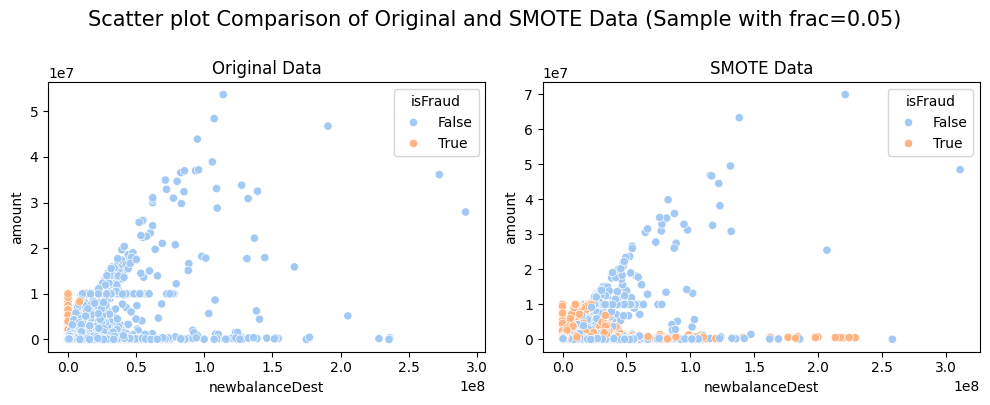

In [ ]:
# plots that show smote creates new fraudulent transactions similar but not identical to original ones
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
frac = 0.05

# First subplot
sns.scatterplot(x="newbalanceDest", y="amount", hue="isFraud", data=df.sample(frac=frac, random_state=42), palette="pastel", ax=axes[0])
axes[0].set_title("Original Data")

# Second subplot
sns.scatterplot(x="newbalanceDest", y="amount", hue="isFraud", data=smote_df.sample(frac=frac, random_state=42), palette="pastel", ax=axes[1])
axes[1].set_title("SMOTE Data")

fig.suptitle('Scatter plot Comparison of Original and SMOTE Data (Sample with frac=0.05)', fontsize=15, y=1)
plt.tight_layout()
plt.show()

/Users/kayi/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


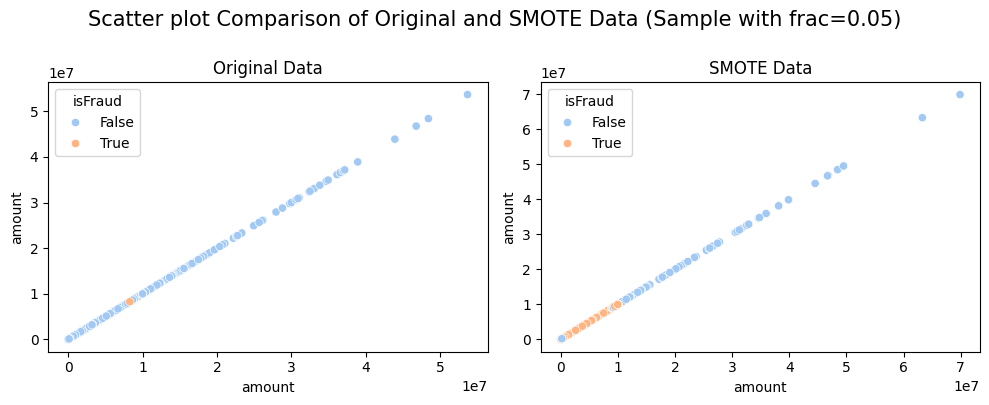

In [ ]:
# plots that show smote creates new fraudulent transactions similar but not identical to original ones
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
frac = 0.05

# First subplot
sns.scatterplot(x="amount", y="amount", hue="isFraud", data=df.sample(frac=frac, random_state=42), palette="pastel", ax=axes[0])
axes[0].set_title("Original Data")

# Second subplot
sns.scatterplot(x="amount", y="amount", hue="isFraud", data=smote_df.sample(frac=frac, random_state=42), palette="pastel", ax=axes[1])
axes[1].set_title("SMOTE Data")

fig.suptitle('Scatter plot Comparison of Original and SMOTE Data (Sample with frac=0.05)', fontsize=15, y=1)
plt.tight_layout()
plt.show()

# Logistic Regression

=== Performance WITHOUT SMOTE ===
              precision    recall  f1-score   support

       False       1.00      1.00      1.00   1270881
        True       0.00      0.00      0.00      1643

    accuracy                           1.00   1272524
   macro avg       0.50      0.50      0.50   1272524
weighted avg       1.00      1.00      1.00   1272524

AUC-ROC: 0.8903


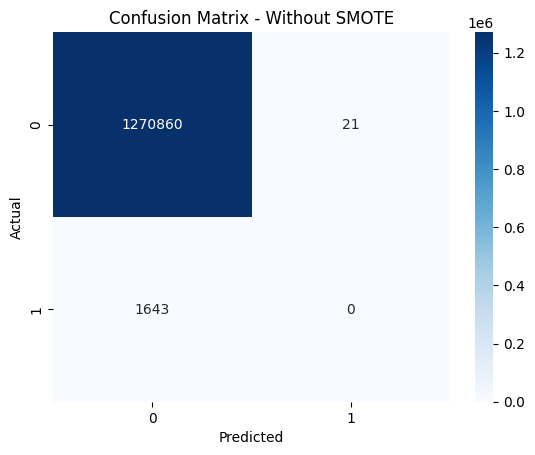

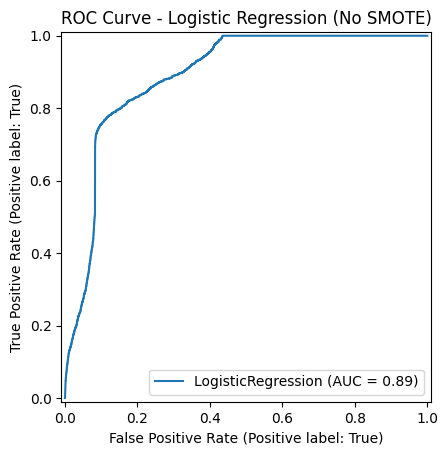

In [ ]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE


# Drop leakage-prone columns
cols_to_drop = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

X_train_clean = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test_clean = X_test.drop(columns=cols_to_drop, errors='ignore')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

# Logistic Regression WITHOUT SMOTE
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_no_smote = log_reg.predict(X_test_scaled)
y_prob_no_smote = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Performance WITHOUT SMOTE ===")
print(classification_report(y_test, y_pred_no_smote))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_no_smote):.4f}")

sns.heatmap(confusion_matrix(y_test, y_pred_no_smote), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Without SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

RocCurveDisplay.from_estimator(log_reg, X_test_scaled, y_test)
plt.title("ROC Curve - Logistic Regression (No SMOTE)")
plt.show()


The model classifies everything as legitimate (non-fraud).
It detects zero fraud cases correctly — recall = 0.

However, it still achieves accuracy ≈ 100%, because fraud cases are extremely rare (≈ 0.1%).

AUC-ROC = 0.89 shows some separability in predicted probabilities, but the 0.5 cutoff means it never actually labels any transactions as fraud.

A classic symptom of class imbalance:
The model learned to “play it safe” and predict the majority class every time.

=== Performance WITH SMOTE ===
              precision    recall  f1-score   support

       False       1.00      0.57      0.72   1270881
        True       0.00      1.00      0.01      1643

    accuracy                           0.57   1272524
   macro avg       0.50      0.78      0.36   1272524
weighted avg       1.00      0.57      0.72   1272524

AUC-ROC: 0.8981


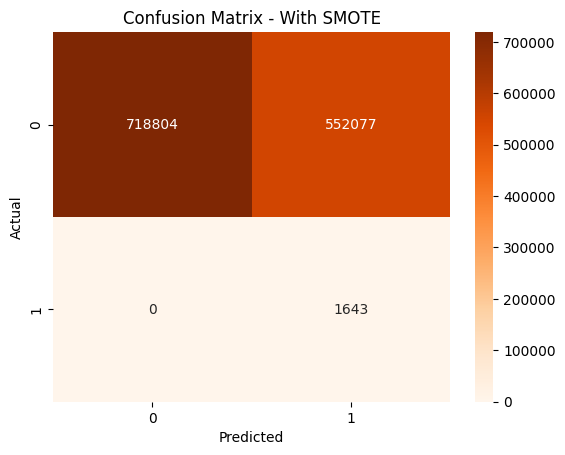

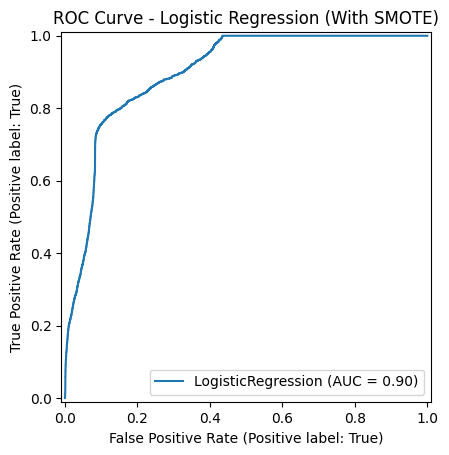

In [ ]:
# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_smoted, y_train_smoted = smote.fit_resample(X_train_clean, y_train)

# Re-scale the SMOTEd data
X_train_smoted_scaled = scaler.fit_transform(X_train_smoted)

# Logistic Regression WITH SMOTE
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_train_smoted_scaled, y_train_smoted)

y_pred_smote = log_reg_smote.predict(X_test_scaled)
y_prob_smote = log_reg_smote.predict_proba(X_test_scaled)[:, 1]

print("=== Performance WITH SMOTE ===")
print(classification_report(y_test, y_pred_smote))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_smote):.4f}")

sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - With SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

RocCurveDisplay.from_estimator(log_reg_smote, X_test_scaled, y_test)
plt.title("ROC Curve - Logistic Regression (With SMOTE)")
plt.show()

The model labels almost everything as fraud.

It catches every actual fraud (recall = 1.00)

But it also wrongly flags ≈ 550 k legitimate transactions (precision ≈ 0).

Accuracy drops to ~57% since half of all predictions are false alarms.

AUC-ROC = 0.90 — only a tiny increase, meaning the underlying probability distribution didn’t change much, just the classification threshold.

SMOTE fixed the recall problem but destroyed precision.
It made the model hypersensitive, predicting “fraud” everywhere.

- SMOTE helped recall but at the cost of extreme overprediction.
- Logistic Regression is linear so it struggles to separate overlapping classes after oversampling synthetic data.
- The model’s probability calibration is fine (AUC ≈ 0.9), but the 0.5 threshold makes predictions swing between “all 0” and “all 1”.

Can try:
- Use class weights instead of SMOTE
- Tune the decision threshold
- Reduce the SMOTE ratio
- Use cross-validation for threshold selection

/var/folders/hz/w33z2_s56bv9417650gj0c5h0000gn/T/ipykernel_61079/4284967948.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df_no_smote.head(15), x='Coefficient', y='Feature', palette='coolwarm')


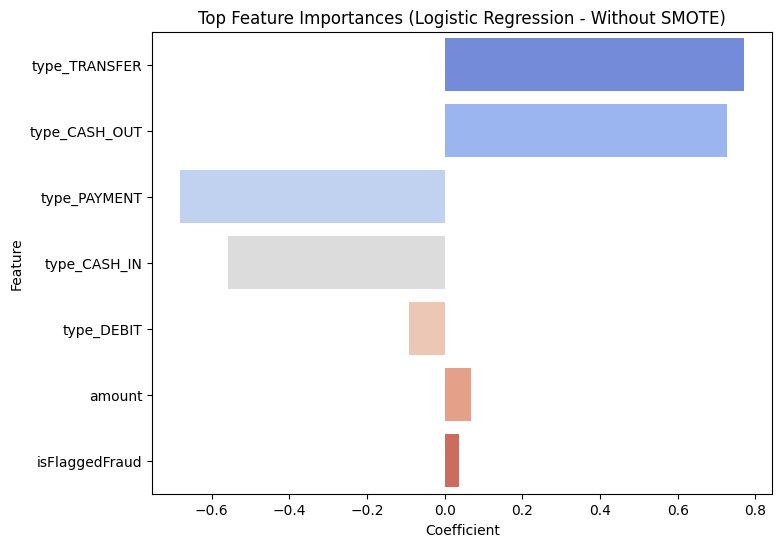

/var/folders/hz/w33z2_s56bv9417650gj0c5h0000gn/T/ipykernel_61079/4284967948.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df_smote.head(15), x='Coefficient', y='Feature', palette='coolwarm')


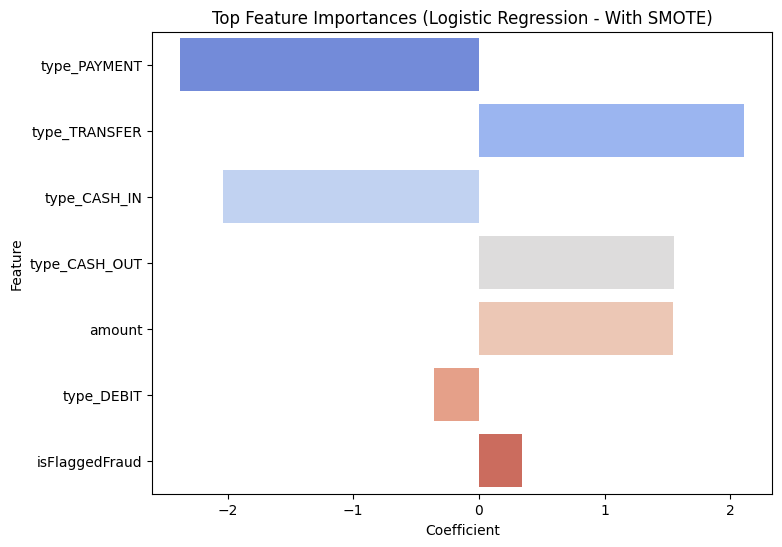

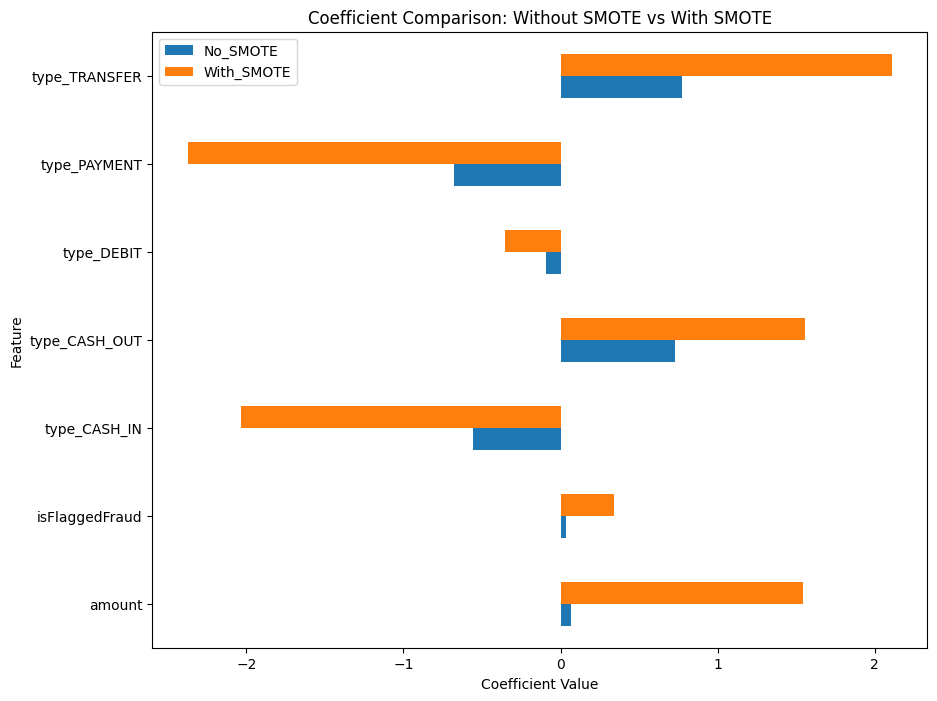

Top most influential features (Without SMOTE):
          Feature  Coefficient  Odds_Ratio  AbsCoeff
6   type_TRANSFER     0.770904    2.161720  0.770904
3   type_CASH_OUT     0.726011    2.066819  0.726011
5    type_PAYMENT    -0.680179    0.506526  0.680179
2    type_CASH_IN    -0.557954    0.572379  0.557954
4      type_DEBIT    -0.091933    0.912167  0.091933
0          amount     0.067960    1.070323  0.067960
1  isFlaggedFraud     0.036719    1.037401  0.036719

Top most influential features (With SMOTE):
          Feature  Coefficient  Odds_Ratio  AbsCoeff
5    type_PAYMENT    -2.374271    0.093082  2.374271
6   type_TRANSFER     2.110093    8.249009  2.110093
2    type_CASH_IN    -2.033524    0.130874  2.033524
3   type_CASH_OUT     1.556323    4.741358  1.556323
0          amount     1.541194    4.670165  1.541194
4      type_DEBIT    -0.353347    0.702334  0.353347
1  isFlaggedFraud     0.340912    1.406229  0.340912


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance (no SMOTE)
coef_df_no_smote = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Coefficient': log_reg.coef_[0]
})
coef_df_no_smote['Odds_Ratio'] = np.exp(coef_df_no_smote['Coefficient'])
coef_df_no_smote['AbsCoeff'] = coef_df_no_smote['Coefficient'].abs()
coef_df_no_smote = coef_df_no_smote.sort_values(by='AbsCoeff', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df_no_smote.head(15), x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Top Feature Importances (Logistic Regression - Without SMOTE)')
plt.show()

# Feature importance (SMOTE)
coef_df_smote = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Coefficient': log_reg_smote.coef_[0]
})
coef_df_smote['Odds_Ratio'] = np.exp(coef_df_smote['Coefficient'])
coef_df_smote['AbsCoeff'] = coef_df_smote['Coefficient'].abs()
coef_df_smote = coef_df_smote.sort_values(by='AbsCoeff', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df_smote.head(15), x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Top Feature Importances (Logistic Regression - With SMOTE)')
plt.show()

# Compare coefficients side by side
coef_compare = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'No_SMOTE': log_reg.coef_[0],
    'With_SMOTE': log_reg_smote.coef_[0]
}).set_index('Feature')

coef_compare.plot(kind='barh', figsize=(10, 8), color=['#1f77b4', '#ff7f0e'])
plt.title('Coefficient Comparison: Without SMOTE vs With SMOTE')
plt.xlabel('Coefficient Value')
plt.show()

# Print top strongest predictors
print("Top most influential features (Without SMOTE):")
print(coef_df_no_smote.head(10))

print("\nTop most influential features (With SMOTE):")
print(coef_df_smote.head(10))


Without SMOTE

- Most important (positive direction):
type_TRANSFER and type_CASH_OUT → these have the largest positive coefficients, meaning these transaction types make fraud more likely.
- Most important (negative direction):
type_PAYMENT and type_CASH_IN → these have large negative coefficients, meaning they are typical of legitimate (non-fraud) transactions.

amount, isFlaggedFraud, and type_DEBIT have small coefficients, meaning they have a minor effect.

Interpretation:
The model (without SMOTE) learned that transfers and cash-outs are the strongest fraud signals, while payments and cash-ins are signs of safe behavior.

With SMOTE

- Strong positive features (fraud indicators):
type_TRANSFER → largest positive coefficient (~2.1).
type_CASH_OUT and amount → also positive and large
- Strong negative features (non-fraud indicators):
type_PAYMENT and type_CASH_IN → very large negative coefficients (~−2)

Interpretation:
After balancing the data with SMOTE, the model became more confident and polarized — fraud is strongly linked to TRANSFER, CASH_OUT, and high amounts, while PAYMENT and CASH_IN clearly indicate legitimate transactions.

In [26]:
# Cell 1 — Load & minimal prep (safe features only)
import pandas as pd
import numpy as np

CSV_PATH = "../data/raw/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv"

df = pd.read_csv(CSV_PATH)

# Keep only types where fraud occurs
VALID_TYPES = ["TRANSFER", "CASH_OUT"]
df = df[df["type"].isin(VALID_TYPES)].copy()

# Safe feature set per Kaggle note (exclude balance columns to avoid leakage)
FEATURES_NUM = ["amount"]     # numeric features
FEATURES_CAT = ["type"]       # categorical (one-hot)
TARGET = "isFraud"

# Basic hygiene
df = df.dropna(subset=FEATURES_NUM + [TARGET] + FEATURES_CAT)
df[TARGET] = df[TARGET].astype(int)

df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0


In [27]:
# Cell 2 — 70/15/15 stratified split
from sklearn.model_selection import StratifiedShuffleSplit

X = df[FEATURES_NUM + FEATURES_CAT].copy()
y = df[TARGET].astype(int).copy()

def stratified_70_15_15(X, y, seed=42):
    s1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    tr_idx, tmp_idx = next(s1.split(X, y))
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_tmp, y_tmp = X.iloc[tmp_idx], y.iloc[tmp_idx]

    s2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    cv_idx, te_idx = next(s2.split(X_tmp, y_tmp))
    return X_tr, y_tr, X_tmp.iloc[cv_idx], y_tmp.iloc[cv_idx], X_tmp.iloc[te_idx], y_tmp.iloc[te_idx]

X_tr, y_tr, X_cv, y_cv, X_te, y_te = stratified_70_15_15(X, y, seed=42)
X_tr.shape, X_cv.shape, X_te.shape


((1939286, 2), (415561, 2), (415562, 2))

In [28]:
# Cell 3 — Single LR model with per-type weights via sample_weight
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

# Paper-style fraud weights
FRAUD_WEIGHT = {"TRANSFER": 70.0, "CASH_OUT": 145.0}

# Build per-sample weights on the training split
sw = np.ones(len(y_tr), dtype=float)
is_fraud = (y_tr.values == 1)

# Need 'type' values aligned with X_tr
type_tr = X_tr["type"].values
sw[(is_fraud) & (type_tr == "TRANSFER")] = FRAUD_WEIGHT["TRANSFER"]
sw[(is_fraud) & (type_tr == "CASH_OUT")] = FRAUD_WEIGHT["CASH_OUT"]

# Preprocess: scale numeric, one-hot categorical
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURES_NUM),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), FEATURES_CAT),
    ],
    remainder="drop",
)

model = make_pipeline(
    pre,
    LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        class_weight=None,     # IMPORTANT: leave None; we pass sample_weight instead
    )
)

# Fit with weights passed to the final estimator via pipeline-step name
model.fit(X_tr, y_tr, logisticregression__sample_weight=sw)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['type'])])),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [29]:
# Cell 4 — Evaluation helpers + test metrics
from sklearn.metrics import confusion_matrix, accuracy_score, average_precision_score, classification_report

def evaluate(name, mdl, X_split, y_split, thr=0.5):
    proba = mdl.predict_proba(X_split)[:, 1]
    yhat = (proba >= thr).astype(int)
    cm = confusion_matrix(y_split, yhat, labels=[0,1])
    acc = accuracy_score(y_split, yhat)
    apr = average_precision_score(y_split, proba)
    print(f"\n=== {name} (thr={thr:.3f}) ===")
    print("Confusion matrix [ [tn fp] [fn tp] ]:\n", cm)
    print(f"Accuracy: {acc:.6f}")
    print(f"PR AUC:   {apr:.6f}")
    print(classification_report(
        y_split, yhat,
        labels=[0,1],
        target_names=["Non-Fraud [0]", "Fraud [1]"],
        digits=4,
        zero_division=0
    ))

evaluate("Validation", model, X_cv, y_cv, thr=0.5)
evaluate("Test",       model, X_te, y_te, thr=0.5)



=== Validation (thr=0.500) ===
Confusion matrix [ [tn fp] [fn tp] ]:
 [[407045   7284]
 [   990    242]]
Accuracy: 0.980090
PR AUC:   0.017838
               precision    recall  f1-score   support

Non-Fraud [0]     0.9976    0.9824    0.9899    414329
    Fraud [1]     0.0322    0.1964    0.0553      1232

     accuracy                         0.9801    415561
    macro avg     0.5149    0.5894    0.5226    415561
 weighted avg     0.9947    0.9801    0.9872    415561


=== Test (thr=0.500) ===
Confusion matrix [ [tn fp] [fn tp] ]:
 [[407002   7328]
 [   991    241]]
Accuracy: 0.979981
PR AUC:   0.019428
               precision    recall  f1-score   support

Non-Fraud [0]     0.9976    0.9823    0.9899    414330
    Fraud [1]     0.0318    0.1956    0.0548      1232

     accuracy                         0.9800    415562
    macro avg     0.5147    0.5890    0.5223    415562
 weighted avg     0.9947    0.9800    0.9871    415562



In [30]:
# Cell 5 — Optional threshold tuning on CV
import numpy as np

def tune_threshold_by_fpr(mdl, X_cv, y_cv, fpr_cap=0.01):
    proba = mdl.predict_proba(X_cv)[:, 1]
    thresholds = np.unique(np.r_[0.0, proba, 1.0])  # scan proba grid
    best_thr, best_rec = 0.5, -1.0

    tn_total = (y_cv == 0).sum()
    tp_total = (y_cv == 1).sum()

    for t in thresholds:
        yhat = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_cv, yhat, labels=[0,1]).ravel()
        fpr = fp / (fp + tn + 1e-12)
        if fpr <= fpr_cap:
            rec = tp / (tp_total + 1e-12)
            if rec > best_rec:
                best_rec, best_thr = rec, t
    return best_thr, best_rec

best_thr, best_rec = tune_threshold_by_fpr(model, X_cv, y_cv, fpr_cap=0.01)
print(f"Chosen threshold: {best_thr:.4f} (CV recall under FPR<=1%: {best_rec:.4f})")

# Evaluate with tuned threshold
evaluate("Validation (tuned)", model, X_cv, y_cv, thr=best_thr)
evaluate("Test (tuned)",       model, X_te, y_te, thr=best_thr)


KeyboardInterrupt: 